# Do heatwaves differ by city size in Germany?

**Research question:** How do heatwave frequency, intensity (peak and average temperature), and duration differ across city sizes, from large cities to rural municipalities, within the same region in Germany?

**LLM note:** The English documentation and code comments in this notebook were revised with the help of an LLM.

The notebook has two parts:

1. Build comparable groups around German large cities: large city, medium-sized city, small town, and rural municipality.
2. Apply the same heatwave definition to all selected places and compare the four city-size classes.

In [1]:
# Imports and display settings
import requests
import json
import time
import pandas as pd
import numpy as np

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 20)

## 1. Building the comparison sample

### Step 1 - Load German municipalities

Wikidata is used to load German municipalities with population, coordinates, municipality key, and city status.

The data is downloaded in population ranges instead of one very large request. This makes the query more stable and avoids repeating API calls during the later matching steps.

In [2]:
# Load German municipalities from Wikidata in smaller population ranges
WIKIDATA_URL = "https://query.wikidata.org/sparql"

HEADERS = {
    "Accept": "application/sparql-results+json",
    "User-Agent": "student-climate-project/1.0"
}


def _fetch_population_range(min_pop, max_pop):
    query = f"""
    SELECT DISTINCT ?place ?placeLabel ?population ?coord ?municipalityKey ?isCity WHERE {{
      ?place wdt:P17 wd:Q183;                     # liegt in Deutschland
             wdt:P31/wdt:P279* wd:Q262166;         # eigenständige deutsche Gemeinde
             wdt:P1082 ?population;                # hat Einwohnerzahl
             wdt:P625 ?coord;                      # hat Koordinaten
             wdt:P439 ?municipalityKey.             # offizieller Gemeindeschlüssel

      BIND(EXISTS {{ ?place wdt:P31/wdt:P279* wd:Q515. }} AS ?isCity)

      FILTER(?population >= {min_pop} && ?population <= {max_pop})

      SERVICE wikibase:label {{ bd:serviceParam wikibase:language "de,en". }}
    }}
    """

    r = requests.get(WIKIDATA_URL, params={"query": query}, headers=HEADERS, timeout=180)
    r.raise_for_status()

    payload = json.loads(r.text, strict=False)
    return payload["results"]["bindings"]


def _fetch_population_range_adaptive(min_pop, max_pop, depth=0, max_depth=10):
    try:
        rows = _fetch_population_range(min_pop, max_pop)
        print(f"  ... Population {min_pop}-{max_pop}: {len(rows)} Gemeinden")
        return rows
    except (requests.HTTPError, requests.exceptions.Timeout, json.JSONDecodeError) as e:
        if depth >= max_depth or max_pop <= min_pop:
            raise RuntimeError(
                f"Populationsbereich {min_pop}-{max_pop} lässt sich auch nach {depth} "
                f"Splits nicht laden. Original-Fehler: {e}"
            ) from e

        mid = (min_pop + max_pop) // 2
        print(f"  ... Population {min_pop}-{max_pop} fehlgeschlagen ({e}), splitte bei {mid}")
        time.sleep(1)

        left = _fetch_population_range_adaptive(min_pop, mid, depth + 1, max_depth)
        right = _fetch_population_range_adaptive(mid + 1, max_pop, depth + 1, max_depth)
        return left + right


def get_all_german_municipalities(min_population=1, max_population=4_000_000):

    rows = _fetch_population_range_adaptive(min_population, max_population)

    places = []
    for row in rows:
        name = row["placeLabel"]["value"]
        pop = int(float(row["population"]["value"]))
        lon, lat = row["coord"]["value"].replace("Point(", "").replace(")", "").split(" ")
        places.append({
            "place": name,
            "wikidata_id": row["place"]["value"].split("/")[-1],
            "population": pop,
            "lat": float(lat),
            "lon": float(lon),
            "municipality_key": row["municipalityKey"]["value"],
            "is_city": row["isCity"]["value"] == "true"
        })

    # Use the municipality code as a unique ID.
    df = pd.DataFrame(places).drop_duplicates(subset="municipality_key")
    return df.reset_index(drop=True)


all_places_df = get_all_german_municipalities(min_population=1)

print(f"Insgesamt geladen: {len(all_places_df)} eigenständige deutsche Gemeinden")
all_places_df.head()

  ... Population 1-4000000: 11340 Gemeinden
Insgesamt geladen: 11117 eigenständige deutsche Gemeinden


,place,wikidata_id,population,lat,lon,municipality_key,is_city
0,Lauterbach,Q622569,13883,50.637778,9.394444,06535011,True
1,Groß-Gerau,Q251689,26614,49.921389,8.481806,06433006,True
2,Zossen,Q226884,21643,52.216667,13.449722,12072477,True
3,Coburg,Q14821,41064,50.258469,10.957869,09463000,True
4,Klötze,Q50877,9666,52.627222,11.164167,15081280,True


### Step 2 - Select large cities

Places with at least 150,000 inhabitants are selected as the large-city starting points.

For each large city, the next steps search for one medium-sized city, one small town, and one rural municipality nearby.

In [3]:
# Select German large cities with at least 150,000 inhabitants
cities_df = (
    all_places_df[all_places_df["population"] >= 150000]
    .sort_values("population", ascending=False)
    .reset_index(drop=True)
)

print(cities_df)
print(f"Anzahl Großstädte: {len(cities_df)}")

                    place wikidata_id  population        lat        lon  \
0                  Berlin         Q64     3782202  52.516667  13.383333   
1                 Hamburg       Q1055     1910160  53.550000  10.000000   
2                 München       Q1726     1510378  48.137500  11.575000   
3                    Köln        Q365     1024621  50.942222   6.957778   
4       Frankfurt am Main       Q1794      775790  50.110556   8.682222   
5               Stuttgart       Q1022      633484  48.777500   9.180000   
6              Düsseldorf       Q1718      631217  51.225556   6.776667   
7                 Leipzig       Q2079      611850  51.340632  12.374733   
8                Dortmund       Q1295      595471  51.513889   7.465278   
9                   Essen       Q2066      586608  51.450833   7.013056   
10                 Bremen      Q24879      577026  53.075833   8.807222   
11                Dresden       Q1731      564904  51.049329  13.738144   
12               Hannover

### Step 3 - Find nearby places

- `haversine_km`: calculates the distance between two coordinates in kilometres.
- `find_places_near_city`: filters the local municipality data by population, place type, and distance.

Using the local table is faster than sending a new Wikidata request for every city.

In [4]:
# Functions for geographic distance and nearby-place filtering
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def find_places_near_city(
    lat,
    lon,
    min_pop,
    max_pop=None,
    radius_km=50,
    place_kind="city"
):

    if place_kind == "city":
        df = all_places_df[all_places_df["is_city"]]
    elif place_kind == "rural":
        df = all_places_df[~all_places_df["is_city"]]
    else:
        raise ValueError("place_kind must be 'city' or 'rural'")

    df = df[df["population"] >= min_pop]
    if max_pop is not None:
        df = df[df["population"] <= max_pop]

    if df.empty:
        return df

    distances = haversine_km(lat, lon, df["lat"].to_numpy(), df["lon"].to_numpy())

    result = df.copy()
    result["distance_km"] = distances
    result = result[result["distance_km"] <= radius_km]

    if result.empty:
        return result

    return (
        result.drop_duplicates(subset="municipality_key")
              .sort_values("distance_km")
              .reset_index(drop=True)
    )

### Step 4 - Select the nearest comparison place

`get_nearest_comparison_place` searches with increasing radii until a suitable place is found.

The large city itself is excluded. Rural municipalities must also satisfy the minimum-distance rule so that very close suburban places are not treated as rural comparisons.

In [5]:
# Find the nearest valid comparison place with increasing search radii
def get_nearest_comparison_place(
    lat,
    lon,
    min_pop,
    max_pop,
    large_city_name,
    place_kind,
    min_distance_km=0
):
    radii = [30, 50, 75, 100, 150, 200]

    for radius in radii:
        df = find_places_near_city(
            lat=lat,
            lon=lon,
            min_pop=min_pop,
            max_pop=max_pop,
            radius_km=radius,
            place_kind=place_kind
        )

        if not df.empty:
            df = df[
                (df["place"].str.lower() != large_city_name.lower()) &
                (df["distance_km"] >= min_distance_km)
            ].copy()

            if not df.empty:
                result = df.iloc[0].copy()
                result["search_radius_km"] = radius
                return result

    return None

### Step 5 - Build the four city-size classes

For every large city, the notebook creates one regional comparison group:

- Large city: at least 150,000 inhabitants
- Medium-sized city: 20,000-149,999 inhabitants
- Small town: 5,000-19,999 inhabitants
- Rural municipality: 1-4,999 inhabitants and at least 15 km from the large city

The result is stored in `comparison_df`.

In [6]:
# Build one four-class comparison group for every large city
matches = []

RURAL_MIN_DISTANCE_KM = 15

for _, row in cities_df.iterrows():
    large_city = row["place"]
    large_pop = int(row["population"])
    lat = row["lat"]
    lon = row["lon"]

    print(f"Suche Vergleichsorte für {large_city} ...")

    categories = {
        "medium": {
            "min_pop": 20000,
            "max_pop": 149999,
            "place_kind": "city",
            "min_distance_km": 0
        },
        "small": {
            "min_pop": 5000,
            "max_pop": 19999,
            "place_kind": "city",
            "min_distance_km": 0
        },
        "rural": {
            "min_pop": 1,
            "max_pop": 4999,
            "place_kind": "rural",
            "min_distance_km": RURAL_MIN_DISTANCE_KM
        }
    }

    matches.append({
        "large_city": large_city,
        "large_city_population": large_pop,
        "comparison_place": large_city,
        "size_class": "large",
        "population": large_pop,
        "distance_km": 0.0,
        "search_radius_km": 0,
        "lat": lat,
        "lon": lon,
        "municipality_key": row.get("municipality_key", None),
        "wikidata_id": row.get("wikidata_id", None)
    })

    for size_class, settings in categories.items():
        result = get_nearest_comparison_place(
            lat=lat,
            lon=lon,
            min_pop=settings["min_pop"],
            max_pop=settings["max_pop"],
            large_city_name=large_city,
            place_kind=settings["place_kind"],
            min_distance_km=settings["min_distance_km"]
        )

        if result is not None:
            matches.append({
                "large_city": large_city,
                "large_city_population": large_pop,
                "comparison_place": result["place"],
                "size_class": size_class,
                "population": int(result["population"]),
                "distance_km": float(result["distance_km"]),
                "search_radius_km": int(result["search_radius_km"]),
                "lat": float(result["lat"]),
                "lon": float(result["lon"]),
                "municipality_key": result["municipality_key"],
                "wikidata_id": result["wikidata_id"]
            })
        else:
            print(f"  Kein gültiger {size_class}-Treffer für {large_city} gefunden.")

comparison_df = pd.DataFrame(matches)
comparison_df

Suche Vergleichsorte für Berlin ...
Suche Vergleichsorte für Hamburg ...
Suche Vergleichsorte für München ...
Suche Vergleichsorte für Köln ...
Suche Vergleichsorte für Frankfurt am Main ...
Suche Vergleichsorte für Stuttgart ...
Suche Vergleichsorte für Düsseldorf ...
Suche Vergleichsorte für Leipzig ...
Suche Vergleichsorte für Dortmund ...
Suche Vergleichsorte für Essen ...
Suche Vergleichsorte für Bremen ...
Suche Vergleichsorte für Dresden ...
Suche Vergleichsorte für Hannover ...
Suche Vergleichsorte für Nürnberg ...
Suche Vergleichsorte für Duisburg ...
Suche Vergleichsorte für Bochum ...
Suche Vergleichsorte für Wuppertal ...
Suche Vergleichsorte für Bielefeld ...
Suche Vergleichsorte für Bonn ...
Suche Vergleichsorte für Mannheim ...
Suche Vergleichsorte für Karlsruhe ...
Suche Vergleichsorte für Münster ...
Suche Vergleichsorte für Augsburg ...
Suche Vergleichsorte für Wiesbaden ...
Suche Vergleichsorte für Mönchengladbach ...
Suche Vergleichsorte für Gelsenkirchen ...
Suche 

,large_city,large_city_population,comparison_place,size_class,population,distance_km,search_radius_km,lat,lon,municipality_key,wikidata_id
0,Berlin,3782202,Berlin,large,3782202,0.000000,0,52.516667,13.383333,11000000,Q64
1,Berlin,3782202,Teltow,medium,27880,14.843479,30,52.402222,13.270556,12069616,Q572512
2,Berlin,3782202,Velten,small,12733,23.976321,30,52.691389,13.175278,12065332,Q585613
3,Berlin,3782202,Gosen-Neu Zittau,rural,3428,26.199325,30,52.393333,13.712778,12067173,Q624117
4,Hamburg,1910160,Hamburg,large,1910160,0.000000,0,53.550000,10.000000,02000000,Q1055
...,...,...,...,...,...,...,...,...,...,...,...
219,Neuss,155163,Berg,rural,1306,73.855658,75,50.555556,6.946944,07131011,Q647551
220,Regensburg,151517,Regensburg,large,151517,0.000000,0,49.016667,12.083333,09362000,Q2978
221,Regensburg,151517,Schwandorf,medium,30239,34.149335,50,49.323600,12.099350,09376161,Q504768
222,Regensburg,151517,Neutraubling,small,14614,8.850619,30,48.987778,12.196389,09375174,Q488625


### Step 6 - Inspect the matching table

The long matching table is reshaped into one row per large city.

This makes it easier to check which medium-sized city, small town, and rural municipality were assigned to each large city.

In [7]:
# Reshape the matching result for an easier visual check
city_order = (
    cities_df
    .sort_values("population", ascending=False)["place"]
    .tolist()
)

comparison_table = comparison_df[
    comparison_df["size_class"].isin(["medium", "small", "rural"])
].pivot(
    index="large_city",
    columns="size_class",
    values="comparison_place"
)

comparison_table = comparison_table[
    ["medium", "small", "rural"]
]

comparison_table = comparison_table.reindex(city_order)

comparison_table = comparison_table.rename(
    columns={
        "medium": "Mittelstadt",
        "small": "Kleinstadt",
        "rural": "Gemeinde"
    }
)

comparison_table.index.name = "Großstadt"

comparison_table

size_class,Mittelstadt,Kleinstadt,Gemeinde
Großstadt,,,
Berlin,Teltow,Velten,Gosen-Neu Zittau
Hamburg,Reinbek,Schenefeld,Stapelfeld
München,Haar,Garching bei München,Baierbrunn
Köln,Hürth,Burscheid,Rheinbreitbach
Frankfurt am Main,Offenbach am Main,Steinbach (Taunus),Messel
Stuttgart,Korntal-Münchingen,Gerlingen,Affalterbach
Düsseldorf,Meerbusch,Burscheid,Buchholz
Leipzig,Markkleeberg,Taucha,Jesewitz
Dortmund,Schwerte,Olfen,Friesenhagen


### Step 7 - Map the selected places

The selected large cities and comparison places are shown on maps of Germany.

Separate panels are used for the four city-size classes to reduce overlap. Larger points indicate comparison places that are shared by several large-city regions.

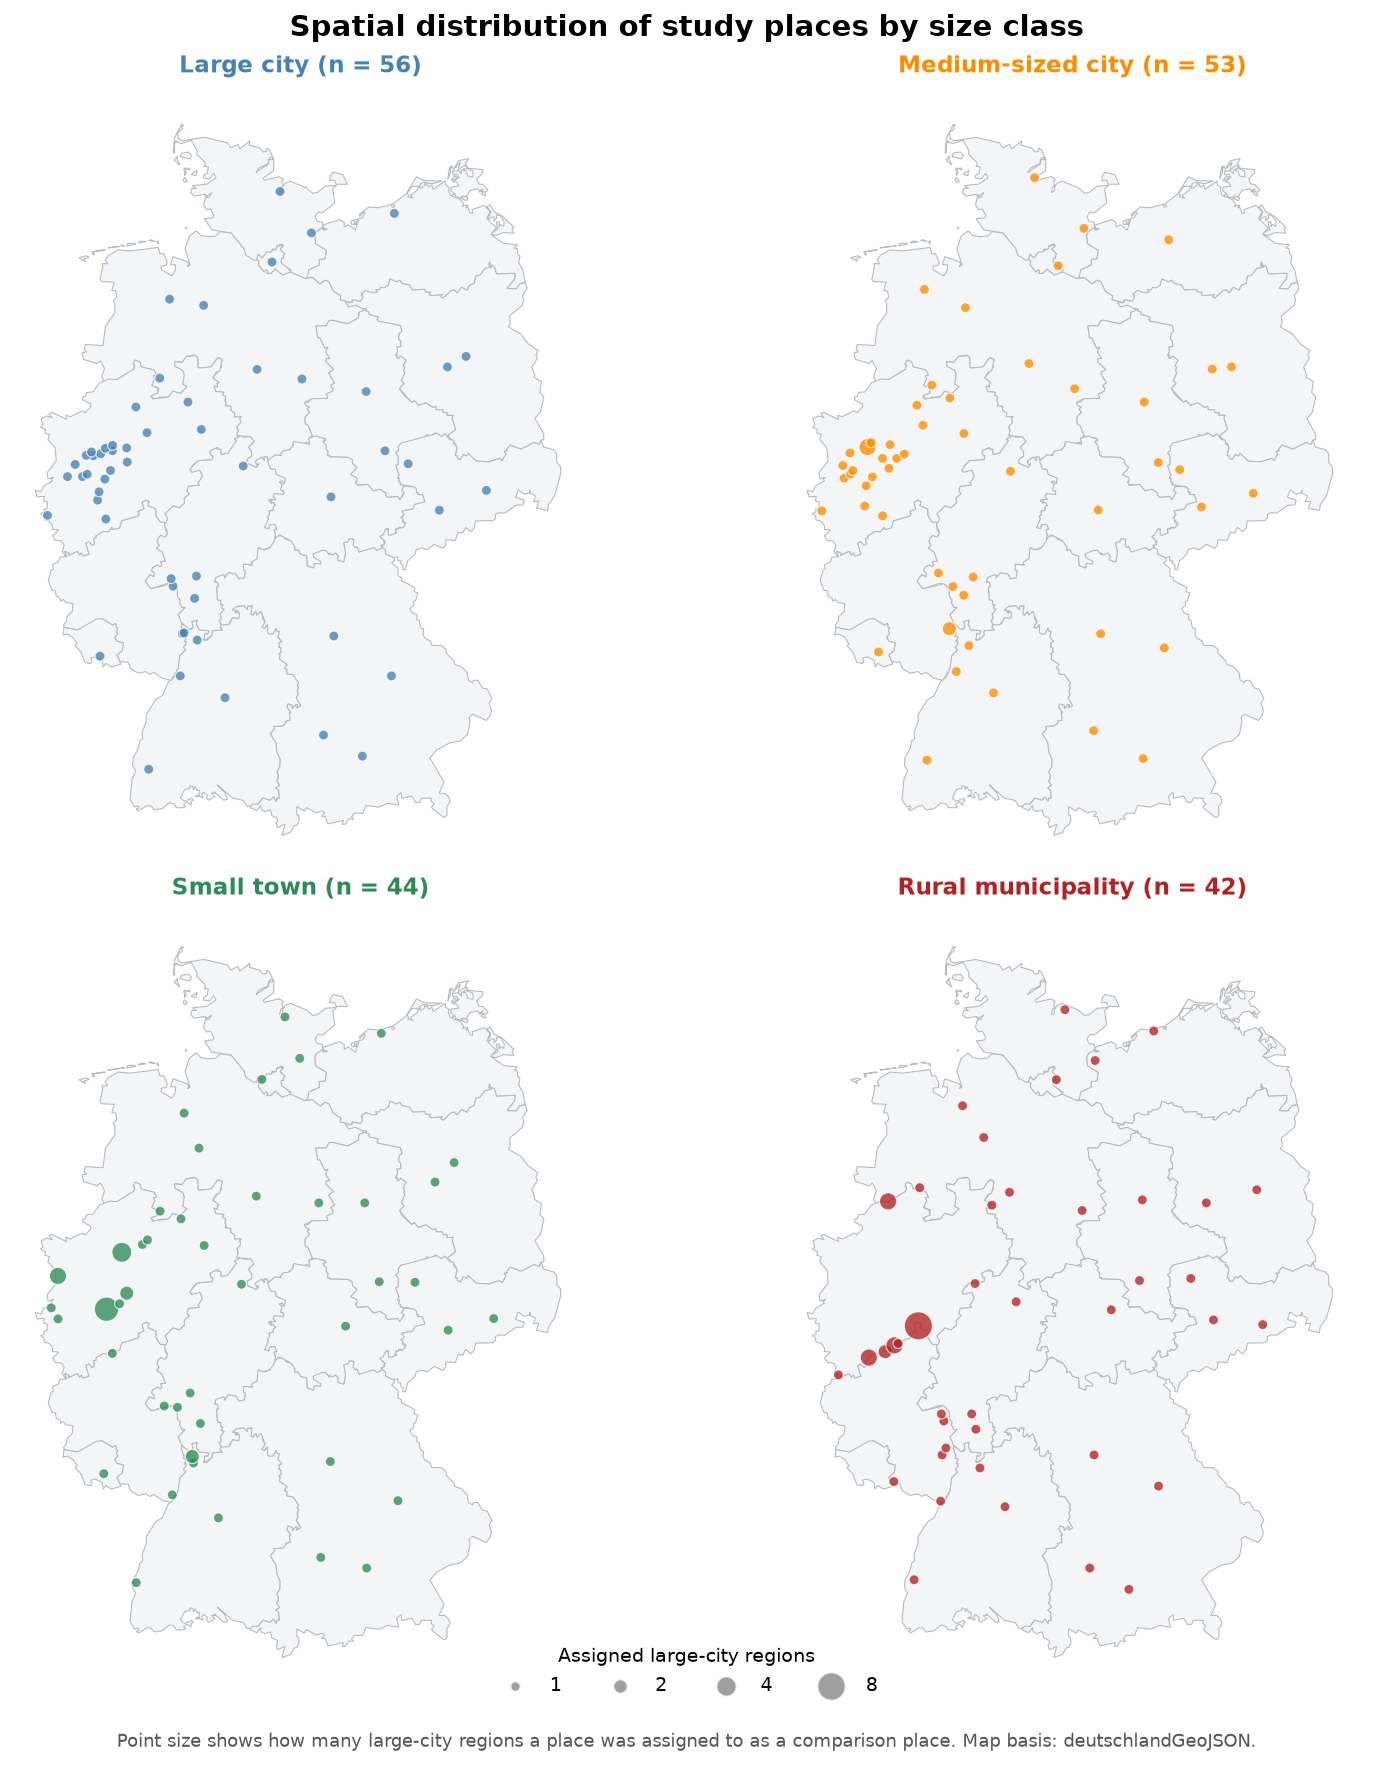

In [8]:
# Map the selected places by city-size class
import matplotlib.pyplot as plt

geojson_url = "https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/4_niedrig.geo.json"
response = requests.get(geojson_url, timeout=30)
response.raise_for_status()
states_geojson = response.json()

# Use the same colors for each city class.
colors = {"large": "steelblue", "medium": "darkorange", "small": "seagreen", "rural": "firebrick"}
class_labels = {"large": "Large city", "medium": "Medium-sized city", "small": "Small town", "rural": "Rural municipality"}
class_order = ["large", "medium", "small", "rural"]

# Count how many large-city regions use each place.
plot_df = (
    comparison_df
    .groupby(["size_class", "lat", "lon"], observed=True, as_index=False)
    .agg(n_shared=("large_city", "nunique"))
)

fig, axes = plt.subplots(2, 2, figsize=(11, 12), dpi=140, constrained_layout=True)
mean_lat = comparison_df["lat"].mean()

for ax, size_class in zip(axes.flat, class_order):
    # Draw the state borders in the background.
    for feature in states_geojson["features"]:
        geom = feature["geometry"]
        polygons = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for polygon in polygons:
            exterior = np.asarray(polygon[0])
            ax.fill(exterior[:, 0], exterior[:, 1], facecolor="#f4f5f7", edgecolor="#b5b9c0", linewidth=0.55, zorder=1)

    # Show one city class per panel.
    sub = plot_df[plot_df["size_class"] == size_class]
    ax.scatter(
        sub["lon"], sub["lat"], s=26 * sub["n_shared"], color=colors[size_class],
        alpha=0.78, edgecolor="white", linewidth=0.6, zorder=2
    )
    ax.set_title(f"{class_labels[size_class]} (n = {len(sub)})", fontsize=12, fontweight="bold", color=colors[size_class])
    ax.set_aspect(1 / np.cos(np.deg2rad(mean_lat)))  # Breitengrad-Korrektur, sonst wirkt die Karte zu breit gezogen
    ax.set_xlim(5.5, 15.5)
    ax.set_ylim(47, 55.5)
    ax.axis("off")

# Add one legend for point size.
max_shared = int(plot_df["n_shared"].max())
size_values = sorted(set(v for v in [1, 2, 4, 8, max_shared] if v <= max_shared))
size_handles = [
    plt.scatter([], [], s=26 * value, color="#777777", alpha=0.7, edgecolor="white", label=f"{value}")
    for value in size_values
]
fig.legend(
    handles=size_handles, title="Assigned large-city regions", loc="lower center",
    ncol=len(size_values), frameon=False, bbox_to_anchor=(0.5, -0.015)
)

fig.suptitle("Spatial distribution of study places by size class", fontsize=15, fontweight="bold")
fig.text(
    0.5, -0.035,
    "Point size shows how many large-city regions a place was assigned to as a comparison place. "
    "Map basis: deutschlandGeoJSON.",
    ha="center", fontsize=9, color="#555555"
)

plt.savefig("RQ2_selected_places_small_multiples.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

### Step 8 - Save the matching result

The complete matching table is saved as `RQ2.csv`.

UTF-8 with BOM is used so German characters are displayed correctly when the file is opened in spreadsheet software.

In [9]:
# Save the complete matching table
comparison_df.to_csv(
    "RQ2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Gespeichert: RQ2.csv")

Gespeichert: RQ2.csv


### Step 9 - Remove duplicate comparison places

Several large cities can share the same nearest comparison place. For the heatwave analysis, each physical place should only be counted once.

`municipality_key` is therefore used to create `unique_places_df`. This avoids downloading the same weather data several times and prevents duplicate places from receiving too much weight in the city-size comparison.

In [10]:
# Keep each physical municipality only once for the heatwave analysis
unique_places_df = (
    comparison_df
    .drop_duplicates(subset="municipality_key")
    .reset_index(drop=True)
)

print(f"comparison_df: {len(comparison_df)} Zeilen")
print(f"unique_places_df: {len(unique_places_df)} eindeutige Orte "
      f"(Ersparnis: {len(comparison_df) - len(unique_places_df)} doppelte Vergleichsorte)")

unique_places_df["size_class"].value_counts().reindex(["large", "medium", "small", "rural"])

comparison_df: 224 Zeilen
unique_places_df: 195 eindeutige Orte (Ersparnis: 29 doppelte Vergleichsorte)


size_class
large     56
medium    53
small     44
rural     42
Name: count, dtype: int64

## 2. Weather data and heatwave detection

### Step 10 - Connect to Open-Meteo

A persistent cache stores historical weather responses because past climate data does not change between notebook runs.

A retry strategy is also used for temporary server and rate-limit errors.

Open-Meteo limits depend on the number of places, days, and variables requested, not only on the number of HTTP requests.

For this reason, the download uses small batches and an adaptive waiting time. The number of selected places is not reduced.

In [11]:
# Open-Meteo client with persistent cache and retry strategy
import os
import openmeteo_requests
import requests_cache
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

CACHE_NAME = "openmeteo_cache"  


def make_client():
    cache_session = requests_cache.CachedSession(
        CACHE_NAME,
        expire_after=-1,
        allowable_codes=[200],
    )
    retry = Retry(
        total=6, backoff_factor=5,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    cache_session.mount("https://", HTTPAdapter(max_retries=retry))
    cache_session.headers.update({"User-Agent": "student-project/1.0"})

    n_cached = len(cache_session.cache.responses)
    print(f"Arbeitsverzeichnis: {os.getcwd()}")
    print(f"Cache-Datei: {os.path.join(os.getcwd(), CACHE_NAME)}.sqlite")
    print(f"Bereits gespeicherte Antworten im Cache: {n_cached}")
    if n_cached == 0:
        print("  -> 0 Eintraege: entweder erster Lauf, oder die vorhandene")
        print("     openmeteo_cache.sqlite mit Fortschritt liegt in einem anderen")
        print("     Ordner als oben angezeigt. Falls ja: Notebook-Kernel neu von")
        print("     dem Ordner aus starten, in dem die Datei tatsaechlich liegt.")

    return openmeteo_requests.Client(session=cache_session)


CLIENT = make_client()

Arbeitsverzeichnis: /Users/mahmood/Desktop/DS-Project/RQ2_RQ4_Abgabe/RQ2
Cache-Datei: /Users/mahmood/Desktop/DS-Project/RQ2_RQ4_Abgabe/RQ2/openmeteo_cache.sqlite
Bereits gespeicherte Antworten im Cache: 127


### Step 11 - Fetch temperatures and detect heatwaves

The main functions are:

- `fetch_tmax_batch`: downloads daily maximum temperature for several places.
- `fetch_tmax_range`: splits long periods into smaller year blocks.
- `compute_doy_thresholds`: calculates the location-specific 98th-percentile threshold from 1961-1990.
- `find_dwd_heatwaves`: detects at least 3 consecutive days above both the local threshold and 28°C.
- `analyze_city_heatwaves_from_data`: applies the method to one place.

Adaptive batch splitting and waiting times are used when the API returns rate-limit errors.

In [12]:
# Functions for weather download, rate-limit handling, and heatwave detection
ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"


class Throttle:
    """Merkt sich eine gemeinsame Pausenlänge über den gesamten Ladevorgang hinweg.
    Anders als eine feste Pause WÄCHST diese Pause bei jedem 429 dauerhaft (statt
    danach wieder auf den Ausgangswert zurückzufallen) und gilt für alle folgenden
    Batches -- auch über mehrere fetch_tmax_range-Aufrufe hinweg, wenn dasselbe
    Throttle-Objekt weitergereicht wird."""

    def __init__(self, pause, max_pause=180):
        self.pause = pause
        self.max_pause = max_pause

    def escalate(self):
        self.pause = min(self.pause * 1.6, self.max_pause)
        return self.pause


class QuotaExhausted(Exception):
    """Wird ausgelöst, wenn selbst ein einzelner Ort bei maximaler Pause noch mit
    429 scheitert. Das ist kein Timing-Problem mehr (dagegen würde Warten helfen),
    sondern ein Hinweis, dass das Stunden- oder Tageskontingent von Open-Meteo
    erschöpft ist -- das lässt sich nur durch Abwarten (bis zur nächsten Stunde
    bzw. bis zum nächsten Tag) und erneutes Ausführen derselben Zelle lösen. Dank
    des dauerhaften HTTP-Caches aus Abschnitt 9 kostet das erneute Ausführen nur
    die Batches, die wirklich noch fehlen -- kein Ort geht verloren."""
    pass


def _fetch_tmax_chunk_adaptive(client, chunk, start_date, end_date, throttle, depth=0, max_depth=5):
    """Holt Tmax für einen Batch von Orten. Schlägt der Batch trotz der eingebauten
    Retry-Logik fehl (z.B. anhaltende 429er), erhöht throttle.escalate() dauerhaft
    die Pause für alle folgenden Batches, es wird entsprechend lange gewartet, und
    der Batch selbst wird in der Mitte halbiert -- dieselbe Eskalationsidee wie bei
    _fetch_population_range_adaptive in Abschnitt 1, nur für Batchgröße statt
    Populationsbereich. Wichtig: kein Ort geht dabei verloren, links und rechts
    zusammen ergeben wieder exakt alle Orte des ursprünglichen Batches.

    Scheitert sogar ein einzelner Ort noch bei maximaler Pause, wird nicht weiter
    gesplittet (das würde nur Zeit kosten, ohne etwas zu lösen), sondern
    QuotaExhausted ausgelöst -- das Kontingent ist dann schlicht für den Moment
    aufgebraucht."""
    params = {
        "latitude": [lat for lat, lon in chunk],
        "longitude": [lon for lat, lon in chunk],
        "start_date": start_date, "end_date": end_date,
        "daily": ["temperature_2m_max"],
        "timezone": "Europe/Berlin",
    }
    try:
        return client.weather_api(ARCHIVE_URL, params=params)
    except Exception as e:
        if len(chunk) <= 1 and throttle.pause >= throttle.max_pause:
            raise QuotaExhausted(
                f"Auch ein einzelner Ort scheitert noch bei maximaler Pause "
                f"({throttle.pause:.0f}s). Das Kontingent von Open-Meteo ist "
                f"vermutlich für diese Stunde/diesen Tag erschöpft. "
                f"Original-Fehler: {e}"
            ) from e

        if depth >= max_depth:
            raise RuntimeError(
                f"Batch mit {len(chunk)} Orten lässt sich auch nach {depth} Splits "
                f"nicht laden. Original-Fehler: {e}"
            ) from e

        cooldown = throttle.escalate()
        print(f"  ... Batch mit {len(chunk)} Orten fehlgeschlagen ({type(e).__name__}: {e}), "
              f"warte {cooldown:.0f}s und splitte (Pause für alle folgenden Batches jetzt {cooldown:.0f}s)...")
        time.sleep(cooldown)

        mid = len(chunk) // 2
        left = _fetch_tmax_chunk_adaptive(client, chunk[:mid], start_date, end_date, throttle, depth + 1, max_depth)
        right = _fetch_tmax_chunk_adaptive(client, chunk[mid:], start_date, end_date, throttle, depth + 1, max_depth)
        return list(left) + list(right)


def fetch_tmax_batch(client, coords, start_date, end_date, throttle, batch_size=15):
    """Holt Tages-Maximaltemperaturen für mehrere Orte gleichzeitig. Alle Orte aus
    coords werden verarbeitet -- batch_size bestimmt nur, wie sie auf Requests
    aufgeteilt werden, nicht ob welche ausgelassen werden."""
    dfs = []
    n_batches = -(-len(coords) // batch_size)

    for b in range(n_batches):
        i = b * batch_size
        chunk = coords[i:i + batch_size]

        t0 = time.perf_counter()
        responses = _fetch_tmax_chunk_adaptive(client, chunk, start_date, end_date, throttle)
        elapsed = time.perf_counter() - t0

        for response in responses:
            daily = response.Daily()
            tmax = daily.Variables(0).ValuesAsNumpy()
            dates = pd.date_range(
                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=daily.Interval()),
                inclusive="left",
            ).tz_localize(None)
            dfs.append(pd.DataFrame({"date": dates, "tmax": tmax}))

        # Pause only after a real API request.
        cache_hit = elapsed < 2.0
        status = "Cache-Treffer" if cache_hit else f"{elapsed:.1f}s, neu geladen"
        print(f"  Batch {b+1}/{n_batches} ok ({len(chunk)} Orte, {status}, aktuelle Pause: {throttle.pause:.0f}s)")
        if not cache_hit:
            time.sleep(throttle.pause)

    return dfs


def fetch_tmax_range(client, coords, start_date, end_date, throttle, batch_size=15, year_chunk=10):
    """Holt Tmax über einen langen Zeitraum, aufgeteilt in Orts-Batches UND Jahres-Blöcke.
    coords wird unverändert und vollständig durchgereicht -- die Anzahl der Orte
    ändert sich durch batch_size/year_chunk nie, nur die Anzahl der HTTP-Requests."""
    start_year, end_year = int(start_date[:4]), int(end_date[:4])

    year_ranges = []
    y = start_year
    while y <= end_year:
        y2 = min(y + year_chunk - 1, end_year)
        year_ranges.append((f"{y}-01-01", f"{y2}-12-31"))
        y = y2 + 1

    all_parts = {i: [] for i in range(len(coords))}
    for chunk_start, chunk_end in year_ranges:
        print(f"Zeitraum {chunk_start[:4]}-{chunk_end[:4]}:")
        t0 = time.perf_counter()
        dfs = fetch_tmax_batch(client, coords, chunk_start, chunk_end, throttle, batch_size=batch_size)
        for i, df in enumerate(dfs):
            all_parts[i].append(df)
        if time.perf_counter() - t0 > 2.0:  # nur pausieren, wenn im Zeitraum echt neu geladen wurde
            time.sleep(throttle.pause)

    return [pd.concat(all_parts[i], ignore_index=True).sort_values("date").reset_index(drop=True)
            for i in range(len(coords))]


THROTTLE = Throttle(pause=20)


def compute_doy_thresholds(ref_df, window=15, percentile=98):
    """Schwellenwert pro Kalendertag: 98. Perzentil aus ±15 Tagen der Referenzperiode."""
    doy = ref_df["doy"].to_numpy()
    tmax = ref_df["tmax"].to_numpy()
    thresholds = {}

    for d in range(1, 366):
        dist = np.abs(doy - d)
        dist = np.minimum(dist, 365 - dist)
        thresholds[d] = np.percentile(tmax[dist <= window], percentile)

    return thresholds


def find_dwd_heatwaves(df, thresholds, min_days=3, fixed_threshold=28.0):
    """Hitzewelle = mind. 3 Tage in Folge über Klima-Schwelle UND über 28°C."""
    df = df.copy()
    df["doy"] = df["date"].dt.dayofyear.clip(upper=365)
    df["threshold"] = df["doy"].map(thresholds)
    df["is_hot"] = (df["tmax"] > df["threshold"]) & (df["tmax"] > fixed_threshold)

    heatwaves, start = [], None
    for i, row in df.iterrows():
        if row["is_hot"] and start is None:
            start = i
        elif not row["is_hot"] and start is not None:
            segment = df.loc[start:i - 1]
            if len(segment) >= min_days:
                heatwaves.append({
                    "start": segment["date"].iloc[0].date(),
                    "end": segment["date"].iloc[-1].date(),
                    "duration_days": len(segment),
                    "max_temp": round(segment["tmax"].max(), 1),
                    "avg_temp": round(segment["tmax"].mean(), 1)
                })
            start = None

    if start is not None:
        segment = df.loc[start:]
        if len(segment) >= min_days:
            heatwaves.append({
                "start": segment["date"].iloc[0].date(),
                "end": segment["date"].iloc[-1].date(),
                "duration_days": len(segment),
                "max_temp": round(segment["tmax"].max(), 1),
                "avg_temp": round(segment["tmax"].mean(), 1)
            })

    return heatwaves


def analyze_city_heatwaves_from_data(ref_df, analysis_df):
    """Verbindet Schwellenwert-Berechnung und Hitzewellen-Suche für einen Ort."""
    ref_df = ref_df.copy()
    ref_df["doy"] = ref_df["date"].dt.dayofyear.clip(upper=365)
    thresholds = compute_doy_thresholds(ref_df)
    return find_dwd_heatwaves(analysis_df, thresholds)

### Step 12 - Smoke test

A small request for three places and one month checks that the weather client and download functions work before the full collection is used.

The expected result is 31 daily values for each place.

In [13]:
# Smoke test: three places for one month
coords = list(zip(unique_places_df["lat"], unique_places_df["lon"]))

test = fetch_tmax_batch(CLIENT, coords[:3], "2025-01-01", "2025-01-31", THROTTLE)
[len(df) for df in test]

  Batch 1/1 ok (3 Orte, Cache-Treffer, aktuelle Pause: 20s)


[31, 31, 31]

### Step 13 - Estimate the full download size

The reference and analysis periods are downloaded as one continuous period from 1961 to 2025.

The Open-Meteo weighting formula is used to estimate the total request size before starting the full collection.

In [14]:
# Estimate the Open-Meteo request weight for the full period
FULL_START, FULL_END = "1961-01-01", "2025-12-31"
n_days_full = (pd.Timestamp(FULL_END) - pd.Timestamp(FULL_START)).days + 1
n_places = len(coords)
weight_total = n_places * (n_days_full / 14) * (1 / 10)  # 1 Variable: temperature_2m_max

daily_quota = 10_000
print(f"Eindeutige Orte: {n_places}")
print(f"Durchgehender Zeitraum {FULL_START} bis {FULL_END}: {n_days_full} Tage")
print(f"Geschätztes Gewicht laut Open-Meteo-Formel (Orte * Tage/14 * Variablen/10): {weight_total:,.0f}")
print(f"Freies Tageskontingent: {daily_quota:,}")
print(f"-> reicht für ca. {weight_total / daily_quota:.1f} Tage Laufzeit (bei taeglich neu verfuegbarem Kontingent)")

Eindeutige Orte: 195
Durchgehender Zeitraum 1961-01-01 bis 2025-12-31: 23741 Tage
Geschätztes Gewicht laut Open-Meteo-Formel (Orte * Tage/14 * Variablen/10): 33,068
Freies Tageskontingent: 10,000
-> reicht für ca. 3.3 Tage Laufzeit (bei taeglich neu verfuegbarem Kontingent)


The full request is larger than the free daily API quota.

The persistent cache makes the process resumable: data that has already been downloaded is reused, and later runs only request missing parts.

### Step 14 - Load the full temperature period

Daily maximum temperatures are loaded for 1961-2025 and then split locally into:

- Reference period: 1961-1990
- Analysis period: 1980-2025

Automatic retries and the persistent cache allow the collection to continue after quota limits without restarting from zero.

In [15]:
# Load 1961-2025 with cache-aware automatic retries
import time as _time  # nur fuer die Zeitstempel in den Log-Ausgaben unten

RETRY_WAIT_HOURS = 2

# Wait before the first large API request.
time.sleep(90)

while True:
    try:
        full_dfs = fetch_tmax_range(CLIENT, coords, FULL_START, FULL_END, THROTTLE, batch_size=15, year_chunk=10)
        break  
    except QuotaExhausted as e:
        now = _time.strftime("%Y-%m-%d %H:%M:%S")
        print(f"[{now}] Kontingent erschöpft: {e}")
        print(f"[{now}] Bereits geladene Orte/Zeiträume liegen sicher im Cache (openmeteo_cache).")
        print(f"[{now}] Warte {RETRY_WAIT_HOURS} Stunden und versuche es automatisch erneut...")
        # Wait before the first large API request.
        THROTTLE.pause = 20
        time.sleep(RETRY_WAIT_HOURS * 60 * 60)

print(f"Fertig! Alle {len(coords)} Orte, Zeitraum {FULL_START} bis {FULL_END}, vollstaendig geladen.")

ref_dfs = [df[(df["date"] >= FULL_START) & (df["date"] <= "1990-12-31")].reset_index(drop=True)
           for df in full_dfs]
analysis_dfs = [df[(df["date"] >= "1980-01-01") & (df["date"] <= FULL_END)].reset_index(drop=True)
                for df in full_dfs]

Zeitraum 1961-1970:
  Batch 1/13 ok (15 Orte, Cache-Treffer, aktuelle Pause: 20s)
  Batch 2/13 ok (15 Orte, Cache-Treffer, aktuelle Pause: 20s)
  Batch 3/13 ok (15 Orte, Cache-Treffer, aktuelle Pause: 20s)
  Batch 4/13 ok (15 Orte, Cache-Treffer, aktuelle Pause: 20s)
  Batch 5/13 ok (15 Orte, Cache-Treffer, aktuelle Pause: 20s)
  Batch 6/13 ok (15 Orte, Cache-Treffer, aktuelle Pause: 20s)
  Batch 7/13 ok (15 Orte, Cache-Treffer, aktuelle Pause: 20s)
  Batch 8/13 ok (15 Orte, Cache-Treffer, aktuelle Pause: 20s)
  ... Batch mit 15 Orten fehlgeschlagen (OpenMeteoRequestsError: failed to request 'https://archive-api.open-meteo.com/v1/archive': Unexpected error while streaming data: timeoutReached), warte 32s und splitte (Pause für alle folgenden Batches jetzt 32s)...
  ... Batch mit 7 Orten fehlgeschlagen (OpenMeteoRequestsError: failed to request 'https://archive-api.open-meteo.com/v1/archive': Unexpected error while streaming data: timeoutReached), warte 51s und splitte (Pause für alle f

### Step 15 - Detect heatwaves for every unique place

The heatwave method is applied to every place in `unique_places_df`.

Each detected heatwave becomes one row in `results_df`, together with its municipality key and city-size class. Failed places are stored separately so they can be checked.

In [16]:
# Detect heatwaves for every unique comparison place
results = []
failed_places = []

for idx, row in unique_places_df.iterrows():
    try:
        heatwaves = analyze_city_heatwaves_from_data(ref_dfs[idx], analysis_dfs[idx])
        for hw in heatwaves:
            results.append({
                "comparison_place": row["comparison_place"],
                "size_class": row["size_class"],
                "municipality_key": row["municipality_key"],
                "population": row["population"],
                **hw
            })
    except Exception as e:
        print(f"  Übersprungen wegen Fehler ({row['comparison_place']}): {e}")
        failed_places.append(row["comparison_place"])

results_df = pd.DataFrame(results)
results_df["year"] = pd.to_datetime(results_df["start"]).dt.year

print(results_df)
print(f"\nGefundene Hitzewellen gesamt: {len(results_df)}")
print(f"Fehlgeschlagen: {failed_places}")

       comparison_place size_class municipality_key  population       start  \
0                Berlin      large         11000000     3782202  1982-05-31   
1                Berlin      large         11000000     3782202  1992-06-01   
2                Berlin      large         11000000     3782202  1992-08-07   
3                Berlin      large         11000000     3782202  1994-07-21   
4                Berlin      large         11000000     3782202  1997-08-23   
...                 ...        ...              ...         ...         ...   
5249  Holzheim am Forst      rural         09375153        1111  2021-06-16   
5250  Holzheim am Forst      rural         09375153        1111  2023-08-18   
5251  Holzheim am Forst      rural         09375153        1111  2024-08-28   
5252  Holzheim am Forst      rural         09375153        1111  2025-06-28   
5253  Holzheim am Forst      rural         09375153        1111  2025-08-12   

             end  duration_days   max_temp   avg_te

## 3. Comparing city-size classes

### Step 16 - Aggregate results by place and city size

First, the event data is summarized to one row per unique place (`place_level`).

The table contains heatwave frequency, average peak temperature, average heatwave temperature, and average duration. Places without a heatwave receive a frequency of zero.

The place-level values are then summarized by the four city-size classes.

In [17]:
# Aggregate event data to place level and then city-size level
size_order = pd.CategoricalDtype(["large", "medium", "small", "rural"], ordered=True)

ANALYSIS_YEARS = 2025 - 1980 + 1

place_level = unique_places_df[["municipality_key", "size_class", "comparison_place"]].merge(
    results_df.groupby("municipality_key").agg(
        n_heatwaves=("start", "count"),
        mean_max_temp=("max_temp", "mean"),
        mean_avg_temp=("avg_temp", "mean"),
        mean_duration=("duration_days", "mean"),
    ),
    on="municipality_key", how="left"
)
place_level["n_heatwaves"] = place_level["n_heatwaves"].fillna(0).astype(int)
place_level["size_class"] = place_level["size_class"].astype(size_order)

summary = place_level.groupby("size_class", observed=False).agg(
    n_orte=("municipality_key", "nunique"),
    gesamt_hitzewellen=("n_heatwaves", "sum"),
    mean_hitzewellen_pro_ort=("n_heatwaves", "mean"),
    mean_max_temp=("mean_max_temp", "mean"),
    mean_avg_temp=("mean_avg_temp", "mean"),
    mean_duration=("mean_duration", "mean"),
).reindex(["large", "medium", "small", "rural"])

summary["hitzewellen_pro_ort_und_jahr"] = summary["mean_hitzewellen_pro_ort"] / ANALYSIS_YEARS
summary = summary.round(3)

summary

,n_orte,gesamt_hitzewellen,mean_hitzewellen_pro_ort,mean_max_temp,mean_avg_temp,mean_duration,hitzewellen_pro_ort_und_jahr
size_class,,,,,,,
large,56,1570,28.036,32.959000,31.521999,4.018,0.609
medium,53,1443,27.226,32.856998,31.420000,3.999,0.592
small,44,1146,26.045,32.715000,31.351999,3.976,0.566
rural,42,1095,26.071,32.587002,31.240999,3.986,0.567


### Step 17 - Regional comparison with the large city

For each large-city region, the comparison place is evaluated relative to its own large city:

`difference = comparison place - large city`

This controls for regional climate differences. A value of zero means no difference from the large city.

The plot shows the mean regional difference and a 95% bootstrap confidence interval for each city-size class.

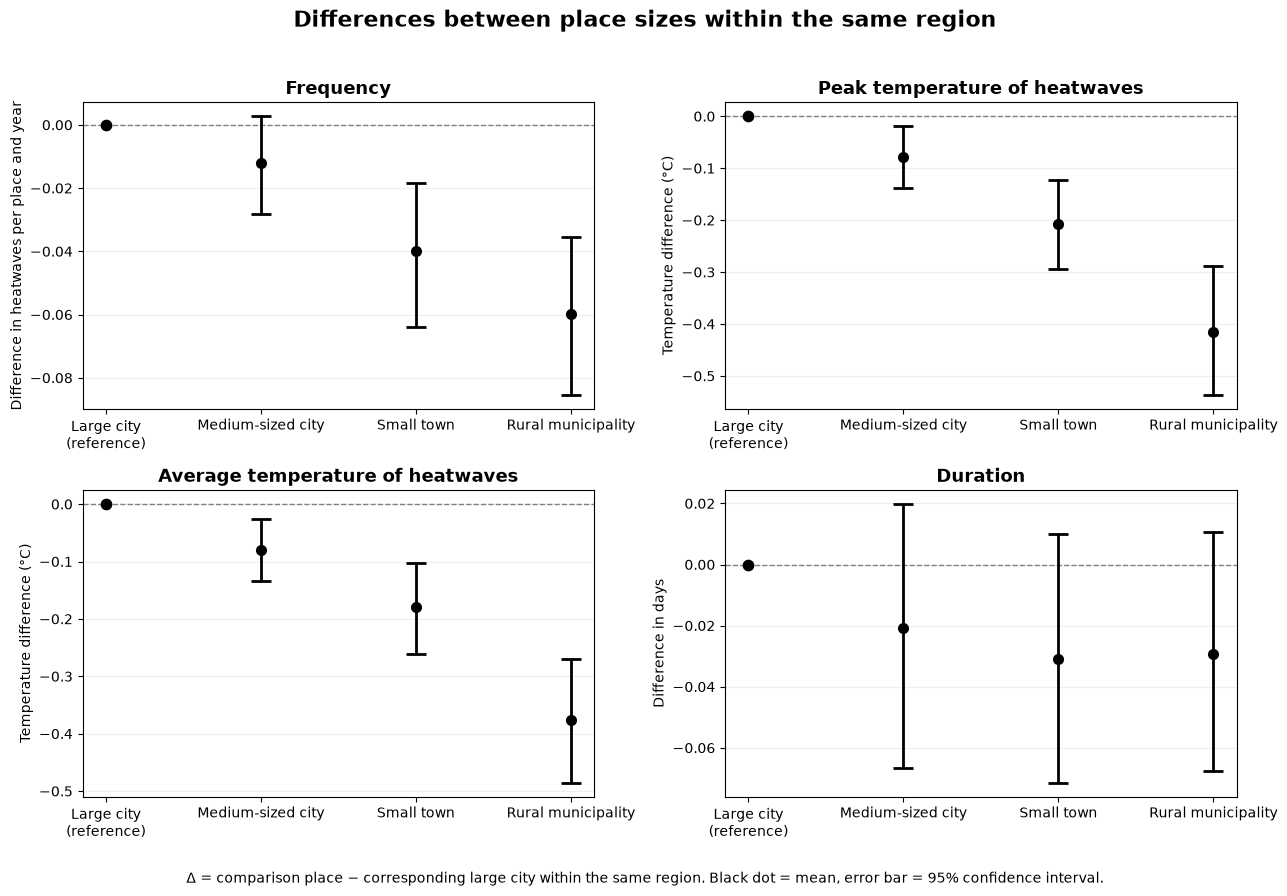

In [18]:
# Compare each place with the large city from the same region
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_order = ["large", "medium", "small", "rural"]
class_labels = {"large": "Large city\n(reference)", "medium": "Medium-sized city", "small": "Small town", "rural": "Rural municipality"}
x_positions = {size_class: i for i, size_class in enumerate(class_order)}

regional = comparison_df[["large_city", "municipality_key", "size_class"]].merge(
    place_level.drop(columns="size_class"),
    on="municipality_key",
    how="left"
)
regional["size_class"] = pd.Categorical(regional["size_class"], categories=class_order, ordered=True)
regional["heatwaves_per_year"] = regional["n_heatwaves"] / ANALYSIS_YEARS

metrics = [
    ("heatwaves_per_year", "Frequency", "Difference in heatwaves per place and year"),
    ("mean_max_temp", "Peak temperature of heatwaves", "Temperature difference (°C)"),
    ("mean_avg_temp", "Average temperature of heatwaves", "Temperature difference (°C)"),
    ("mean_duration", "Duration", "Difference in days"),
]

# Compare each place with its large city.
for column, _, _ in metrics:
    large_city_values = regional[regional["size_class"] == "large"].set_index("large_city")[column]
    regional[f"delta_{column}"] = regional[column] - regional["large_city"].map(large_city_values)


def bootstrap_ci(values, n_boot=1000, confidence=95):
    """Mittelwert + Bootstrap-Konfidenzintervall einer Wertereihe -- dieselbe Bootstrap-Methode,
    die bisher intern in sns.pointplot steckte, hier nur direkt aufgerufen. Dadurch bleibt volle
    Kontrolle darueber, dass fuer "large" unten bewusst KEIN Intervall berechnet/gezeichnet wird."""
    values = np.asarray(values)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    boot_means = sns.algorithms.bootstrap(values, func=np.mean, n_boot=n_boot, seed=42)
    alpha = (100 - confidence) / 2
    return values.mean(), np.percentile(boot_means, alpha), np.percentile(boot_means, 100 - alpha)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (column, title, ylabel) in zip(axes.flat, metrics):
    # The large-city reference stays at zero.
    ax.scatter(x_positions["large"], 0, color="black", s=55, zorder=5)

    for size_class in ["medium", "small", "rural"]:
        mean_value, ci_low, ci_high = bootstrap_ci(regional.loc[regional["size_class"] == size_class, f"delta_{column}"])
        yerr = [[mean_value - ci_low], [ci_high - mean_value]]
        ax.errorbar(
            x_positions[size_class], mean_value, yerr=yerr,
            fmt="o", color="black", markersize=7, capsize=7, capthick=2, linewidth=2, zorder=4
        )

    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(class_order)))
    ax.set_xticklabels([class_labels[c] for c in class_order])
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.2)

fig.suptitle("Differences between place sizes within the same region", fontsize=16, fontweight="bold")
fig.text(
    0.5, 0.01,
    "Δ = comparison place − corresponding large city within the same region. "
    "Black dot = mean, error bar = 95% confidence interval.",
    ha="center", fontsize=10
)
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig("RQ2_regional_delta.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 18 - Long-term development by city size

Yearly heatwave frequency, intensity, and duration are calculated separately for the four city-size classes from 1980 to 2025.

A centred 5-year rolling average is used to make the long-term development easier to see. Frequency is normalized by the number of places with available weather data in each year.

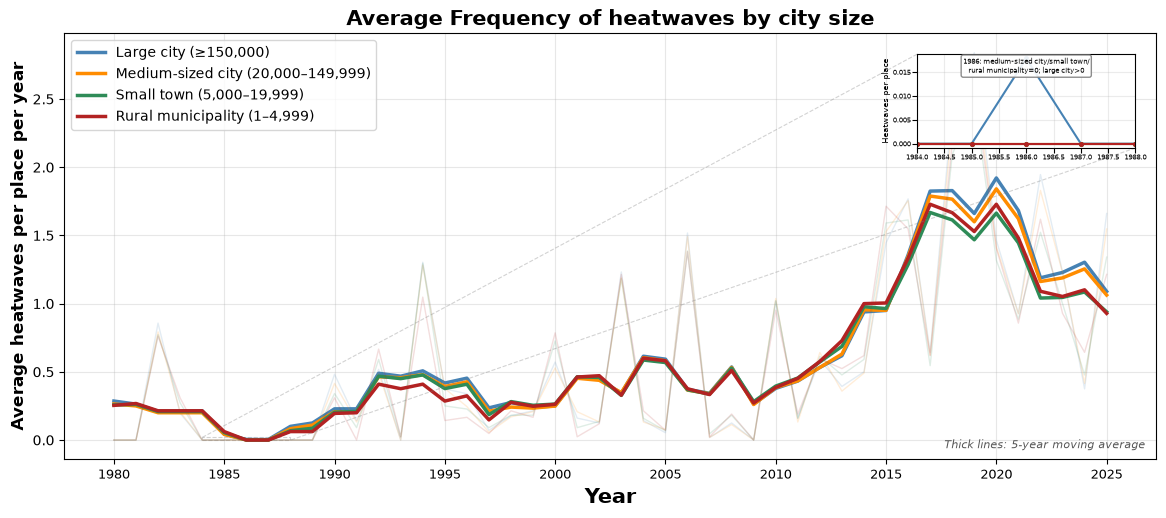

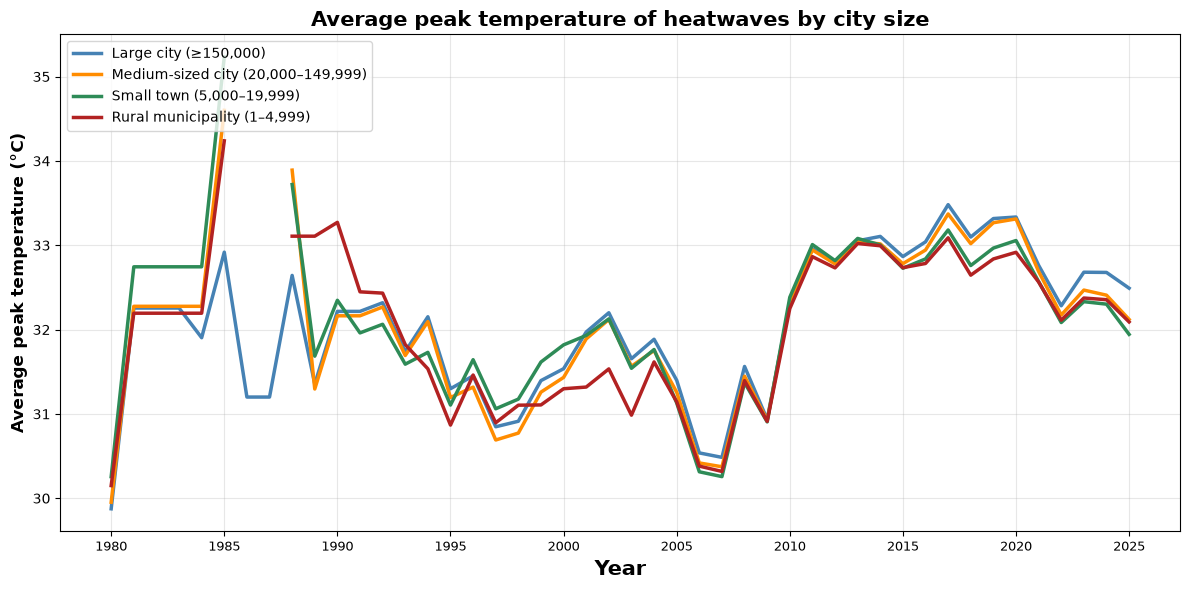

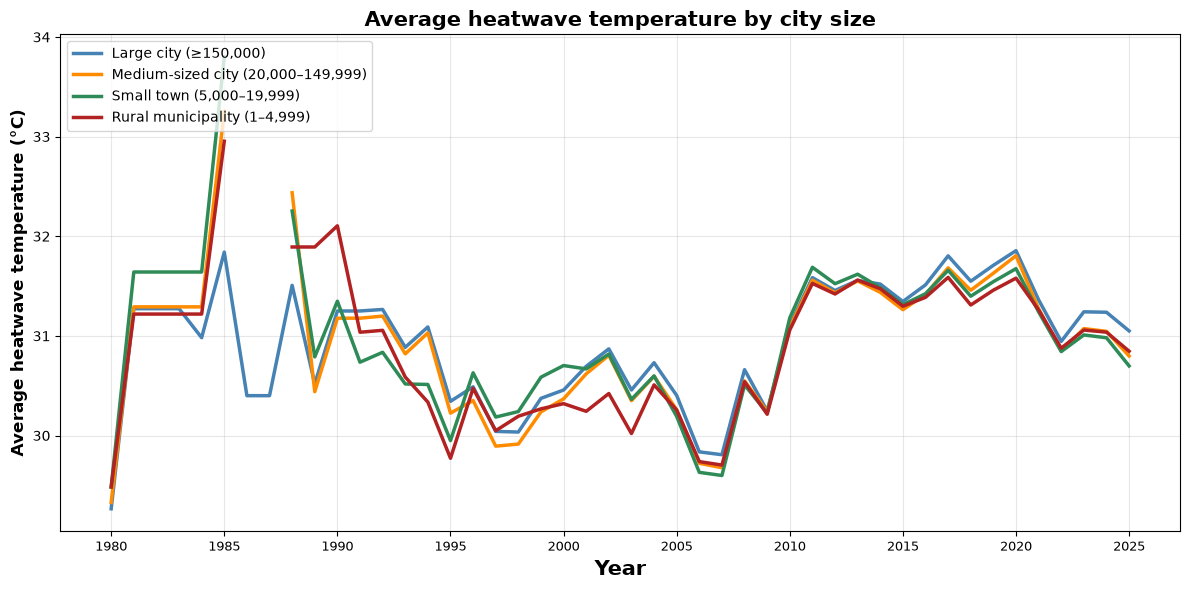

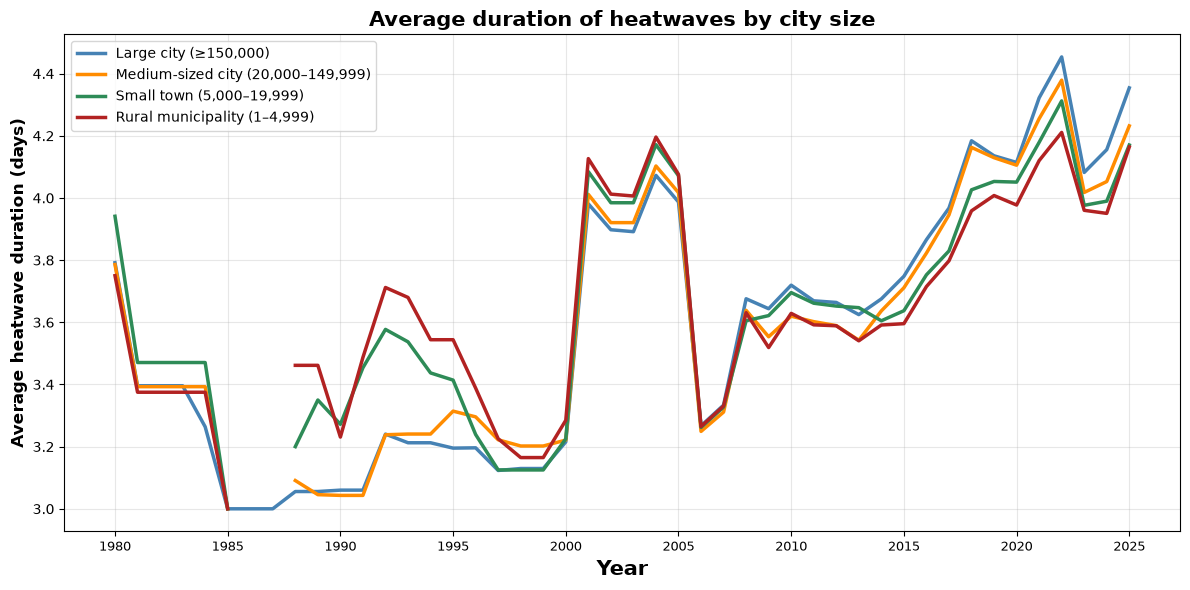

Alle Jahre haben in jeder Größenklasse ≥90% Orte-Abdeckung.


In [19]:
# Build yearly city-size series and 5-year rolling averages
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

n_orte_per_class = place_level.groupby("size_class", observed=False)["municipality_key"].nunique()

# Count places with weather data for each year.
place_years = []
for idx, row in unique_places_df.iterrows():
    for y in analysis_dfs[idx]["date"].dt.year.unique():
        place_years.append({"year": int(y), "size_class": row["size_class"]})
coverage = (pd.DataFrame(place_years)
            .groupby(["year", "size_class"], observed=False).size()
            .rename("n_orte_mit_daten").reset_index())

all_years = pd.DataFrame(
    [(y, s) for y in range(1980, 2026) for s in ["large", "medium", "small", "rural"]],
    columns=["year", "size_class"]
)

yearly = results_df.groupby(["year", "size_class"], observed=False).agg(
    n_heatwaves=("start", "count"),
    mean_max_temp=("max_temp", "mean"),
    mean_avg_temp=("avg_temp", "mean"),
    mean_duration=("duration_days", "mean"),
).reset_index()

yearly = all_years.merge(yearly, on=["year", "size_class"], how="left").merge(
    coverage, on=["year", "size_class"], how="left"
)
yearly["n_heatwaves"] = yearly["n_heatwaves"].fillna(0)
yearly["n_orte_mit_daten"] = yearly["n_orte_mit_daten"].fillna(0).astype(int)
yearly["hitzewellen_pro_ort"] = np.where(
    yearly["n_orte_mit_daten"] > 0, yearly["n_heatwaves"] / yearly["n_orte_mit_daten"], np.nan
)
yearly["size_class"] = yearly["size_class"].astype(size_order)

colors = {"large": "steelblue", "medium": "darkorange", "small": "seagreen", "rural": "firebrick"}
class_labels = {"large": "Large city (≥150,000)", "medium": "Medium-sized city (20,000–149,999)", "small": "Small town (5,000–19,999)", "rural": "Rural municipality (1–4,999)"}

# Use the same colors for each city class.
metrics_yearly = [
    (
        "hitzewellen_pro_ort",
        "Average Frequency of heatwaves by city size",
        "Average heatwaves per place per year",
        "RQ2_heatwaves_yearly_trend_frequency.png"
    ),
    (
        "mean_max_temp",
        "Average peak temperature of heatwaves by city size",
        "Average peak temperature (°C)",
        "RQ2_heatwaves_yearly_trend_peak_temp.png"
    ),
    (
        "mean_avg_temp",
        "Average heatwave temperature by city size",
        "Average heatwave temperature (°C)",
        "RQ2_heatwaves_yearly_trend_avg_temp.png"
    ),
    (
        "mean_duration",
        "Average duration of heatwaves by city size",
        "Average heatwave duration (days)",
        "RQ2_heatwaves_yearly_trend_duration.png"
    ),
]

# Find years for the frequency zoom.
freq_pivot = yearly.pivot(index="year", columns="size_class", values="hitzewellen_pro_ort")

# Do not treat missing data as zero heatwaves.
zoom_condition = (
    (freq_pivot["large"] > 0)
    & (freq_pivot["medium"] == 0)
    & (freq_pivot["small"] == 0)
    & (freq_pivot["rural"] == 0)
)
zoom_years_found = sorted(freq_pivot.index[zoom_condition].tolist())

zoom_window = None
if zoom_years_found:
    # Find continuous year blocks for the zoom.
    zoom_blocks = []
    current_block = [zoom_years_found[0]]
    for y in zoom_years_found[1:]:
        if y == current_block[-1] + 1:
            current_block.append(y)
        else:
            zoom_blocks.append(current_block)
            current_block = [y]
    zoom_blocks.append(current_block)
    largest_zoom_block = max(zoom_blocks, key=len)

    # Add nearby years for context.
    zoom_window = (
        max(1980, largest_zoom_block[0] - 2),
        min(2025, largest_zoom_block[-1] + 2),
    )
else:
    print(
        "Kein Jahr erfüllt die Zoom-Bedingung (Großstadt > 0 und Mittelstadt/Kleinstadt/"
        "Gemeinde == 0 im selben Jahr) -- für die Häufigkeits-Grafik wird kein Zoom-Inset erzeugt."
    )

for col, title, ylabel, filename in metrics_yearly:
    fig, ax = plt.subplots(figsize=(12, 6))
    for size_class in ["large", "medium", "small", "rural"]:
        sub = yearly[yearly["size_class"] == size_class].sort_values("year")

        # Do not treat missing data as zero heatwaves.
        trend = sub[col].rolling(5, min_periods=1, center=True).mean()

        # Find years for the frequency zoom.
        if col == "hitzewellen_pro_ort":
            ax.plot(sub["year"], sub[col], color=colors[size_class], alpha=0.15, linewidth=1)

        # Show the smooth trend as a thicker line.
        ax.plot(sub["year"], trend, color=colors[size_class], linewidth=2.5, label=class_labels[size_class])

    # Find years for the frequency zoom.
    if col == "hitzewellen_pro_ort" and zoom_window is not None:
        zoom_start, zoom_end = zoom_window
        # Keep the zoom box small.
        axins = inset_axes(ax, width="20%", height="22%", loc="upper right", borderpad=1.5)
        for size_class in ["large", "medium", "small", "rural"]:
            sub_zoom = yearly[
                (yearly["size_class"] == size_class)
                & (yearly["year"] >= zoom_start)
                & (yearly["year"] <= zoom_end)
            ].sort_values("year")
            # Show raw yearly values in the zoom.
            axins.plot(
                sub_zoom["year"], sub_zoom[col],
                color=colors[size_class], linewidth=1.5, marker="o", markersize=2.5,
            )
        axins.set_xlim(zoom_start, zoom_end)
        axins.set_ylabel("Heatwaves per place", fontsize=5.5, labelpad=2)
        axins.tick_params(labelsize=5, pad=1)
        axins.grid(alpha=0.25)

        # Create the zoom label from the selected years.
        if len(largest_zoom_block) == 1:
            zoom_years_label = str(largest_zoom_block[0])
        else:
            zoom_years_label = f"{largest_zoom_block[0]}–{largest_zoom_block[-1]}"
        annotation_text = f"{zoom_years_label}: medium-sized city/small town/\nrural municipality=0; large city>0"
        axins.text(
            0.5, 0.97, annotation_text,
            transform=axins.transAxes, ha="center", va="top", fontsize=5,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"),
        )
        # Mark the zoom period in the main chart.
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="gray", alpha=0.35, linestyle="--", linewidth=0.8)

    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("Year", fontsize=15, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12, fontweight="bold")

    # Small clarifying note, frequency plot only: explains what the thick line represents
    if col == "hitzewellen_pro_ort":
        ax.text(
            0.99, 0.02, "Thick lines: 5-year moving average",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="#555555", style="italic",
        )
    # Show x-axis ticks every five years.
    ax.set_xticks(range(1980, 2026, 5))
    ax.tick_params(axis="x", rotation=0, labelsize=9)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left", ncol=1)

    if col == "hitzewellen_pro_ort":
        # Set the plot margins manually.
        fig.subplots_adjust(left=0.07, right=0.98, top=0.93, bottom=0.22)
    else:
        plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

# List years with low data coverage.
n_orte_erwartet = yearly["size_class"].astype(str).map(n_orte_per_class.to_dict())
thin_years = yearly[yearly["n_orte_mit_daten"] < 0.9 * n_orte_erwartet]
if len(thin_years):
    print("Jahre mit <90% Orte-Abdeckung je Größenklasse (Linie dort nur eingeschränkt aussagekräftig):")
    for size_class, grp in thin_years.groupby("size_class", observed=False):
        years_list = sorted(grp["year"].tolist())
        if years_list:
            print(f"  {class_labels[size_class]}: {years_list[0]}–{years_list[-1]} ({len(years_list)} Jahre)")
else:
    print("Alle Jahre haben in jeder Größenklasse ≥90% Orte-Abdeckung.")

### Step 19 - Trend statistics

Linear regression is calculated for every city-size class and heatwave metric.

- `slope`: change per year
- `p-value`: statistical significance of the trend
- `R²`: share of variation explained by time
- `n`: number of years included in the regression

This gives a numerical check of the trends shown in the figures.

In [20]:
# Calculate linear trend statistics for each city-size class
from scipy import stats

def trend_table(yearly_subset):
    rows = []
    for size_class in ["large", "medium", "small", "rural"]:
        sub = yearly_subset[yearly_subset["size_class"] == size_class]
        for col, label in [("hitzewellen_pro_ort", "Häufigkeit"), ("mean_max_temp", "Spitzentemp."),
                            ("mean_avg_temp", "Durchschnittstemp."), ("mean_duration", "Dauer")]:
            valid = sub.dropna(subset=[col])
            if len(valid) < 2:
                rows.append({"size_class": class_labels[size_class], "kennzahl": label,
                              "slope_pro_jahr": np.nan, "p_wert": np.nan, "r2": np.nan,
                              "signifikant": "zu wenig Daten", "n": len(valid)})
                continue
            slope, intercept, r, p, se = stats.linregress(valid["year"], valid[col])
            rows.append({"size_class": class_labels[size_class], "kennzahl": label,
                         "slope_pro_jahr": round(slope, 4), "p_wert": round(p, 4),
                         "r2": round(r**2, 3), "signifikant": "ja" if p < 0.05 else "nein",
                         "n": len(valid)})
    return pd.DataFrame(rows)

print("Trendstatistik, gesamter Zeitraum (1980–2025):")
trend_full = trend_table(yearly)
trend_full

Trendstatistik, gesamter Zeitraum (1980–2025):


,size_class,kennzahl,slope_pro_jahr,p_wert,r2,signifikant,n
0,"Large city (≥150,000)",Häufigkeit,0.0326,0.0000,0.373,ja,46
1,"Large city (≥150,000)",Spitzentemp.,0.0394,0.1100,0.071,nein,37
2,"Large city (≥150,000)",Durchschnittstemp.,0.0214,0.2532,0.037,nein,37
3,"Large city (≥150,000)",Dauer,0.0280,0.0107,0.172,ja,37
4,"Medium-sized city (20,000–149,999)",Häufigkeit,0.0320,0.0000,0.383,ja,46
5,"Medium-sized city (20,000–149,999)",Spitzentemp.,0.0359,0.1637,0.056,nein,36
6,"Medium-sized city (20,000–149,999)",Durchschnittstemp.,0.0190,0.3333,0.028,nein,36
7,"Medium-sized city (20,000–149,999)",Dauer,0.0246,0.0329,0.127,ja,36
8,"Small town (5,000–19,999)",Häufigkeit,0.0291,0.0000,0.378,ja,46
9,"Small town (5,000–19,999)",Spitzentemp.,0.0237,0.3293,0.027,nein,37


The same regressions are repeated for 1991-2025.

This checks whether the overlap between the 1961-1990 reference period and the 1980-2025 analysis period affects the trend results.

In [21]:
# Repeat the trend analysis for 1991-2025
yearly_no_overlap = yearly[yearly["year"] >= 1991]
trend_no_overlap = trend_table(yearly_no_overlap)
trend_no_overlap

,size_class,kennzahl,slope_pro_jahr,p_wert,r2,signifikant,n
0,"Large city (≥150,000)",Häufigkeit,0.0410,0.0005,0.313,ja,35
1,"Large city (≥150,000)",Spitzentemp.,0.0674,0.0245,0.153,ja,33
2,"Large city (≥150,000)",Durchschnittstemp.,0.0433,0.0527,0.116,nein,33
3,"Large city (≥150,000)",Dauer,0.0332,0.0206,0.161,ja,33
4,"Medium-sized city (20,000–149,999)",Häufigkeit,0.0400,0.0004,0.320,ja,35
5,"Medium-sized city (20,000–149,999)",Spitzentemp.,0.0646,0.0302,0.143,ja,33
6,"Medium-sized city (20,000–149,999)",Durchschnittstemp.,0.0418,0.0597,0.110,nein,33
7,"Medium-sized city (20,000–149,999)",Dauer,0.0289,0.0443,0.124,ja,33
8,"Small town (5,000–19,999)",Häufigkeit,0.0352,0.0007,0.300,ja,35
9,"Small town (5,000–19,999)",Spitzentemp.,0.0506,0.0637,0.103,nein,34


### Step 20 - Test differences between city-size classes

A Kruskal-Wallis test compares the four city-size classes for each heatwave metric.

The test uses one aggregated value per unique place rather than individual heatwave events. This prevents places with many events from receiving too much weight.

In [22]:
# Compare city-size classes with Kruskal-Wallis tests
from scipy import stats

metrics = [
    ("n_heatwaves", "Häufigkeit (Hitzewellen pro Ort)"),
    ("mean_max_temp", "Intensität (Spitzentemperatur der Hitzewellen)"),
    ("mean_avg_temp", "Intensität (Durchschnittstemperatur der Hitzewellen)"),
    ("mean_duration", "Dauer"),
]

for col, label in metrics:
    groups = [
        place_level.loc[place_level["size_class"] == cls, col].dropna()
        for cls in ["large", "medium", "small", "rural"]
    ]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) < 2:
        print(f"{label}: zu wenige Gruppen mit Daten für einen Test.")
        continue

    h, p = stats.kruskal(*groups)
    signif = "signifikant" if p < 0.05 else "nicht signifikant"
    print(f"{label}: H={h:.3f}, p={p:.4f} ({signif}), n pro Gruppe = {[len(g) for g in groups]}")

Häufigkeit (Hitzewellen pro Ort): H=2.477, p=0.4795 (nicht signifikant), n pro Gruppe = [56, 53, 44, 42]
Intensität (Spitzentemperatur der Hitzewellen): H=7.792, p=0.0505 (nicht signifikant), n pro Gruppe = [56, 53, 44, 42]
Intensität (Durchschnittstemperatur der Hitzewellen): H=4.748, p=0.1912 (nicht signifikant), n pro Gruppe = [56, 53, 44, 42]
Dauer: H=1.636, p=0.6512 (nicht signifikant), n pro Gruppe = [56, 53, 44, 42]


## 4. Save the analysis results

The event-level, place-level, and city-size summary tables are exported as CSV files for later use, including the project website.

In [23]:
# Export the final RQ2 result tables
results_df.to_csv("RQ2_heatwaves_events.csv", index=False, encoding="utf-8-sig")
place_level.to_csv("RQ2_heatwaves_per_place.csv", index=False, encoding="utf-8-sig")
summary.to_csv("RQ2_heatwaves_summary_by_sizeclass.csv", encoding="utf-8-sig")

print("Gespeichert: RQ2_heatwaves_events.csv, RQ2_heatwaves_per_place.csv, RQ2_heatwaves_summary_by_sizeclass.csv")

Gespeichert: RQ2_heatwaves_events.csv, RQ2_heatwaves_per_place.csv, RQ2_heatwaves_summary_by_sizeclass.csv


## Method note

The heatwave definition uses at least 3 consecutive days above both the location-specific 98th-percentile threshold and 28°C. The reference period is 1961-1990 and the analysis period is 1980-2025.

City-size statistics are based on unique municipalities. This is important because several large-city regions can share the same comparison place.

The regional analysis keeps the original large-city/comparison-place pairings because each pairing represents a separate within-region comparison.